# 04 — Your first CNN

**Day 1 · Notebook 4 of 4**

We'll train a small CNN on FashionMNIST. The training loop is **fully
explicit** — no Lightning, no `model.fit`. You'll see every step:

`forward → loss → backward → step → zero_grad`.

Target: > 85% test accuracy in a few minutes of CPU training.

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms as T
from tqdm.auto import tqdm

from cvcourse import get_device, count_params, show_grid

device = get_device()
print("device:", device)

device: mps


## 1. Data

In [2]:
pipeline = T.Compose([T.ToTensor(), T.Normalize((0.2860,), (0.3530,))])
train_ds = torchvision.datasets.FashionMNIST("../data", train=True,  download=True, transform=pipeline)
test_ds  = torchvision.datasets.FashionMNIST("../data", train=False, download=True, transform=pipeline)

train_loader = DataLoader(train_ds, batch_size=128, shuffle=True,  num_workers=0)
test_loader  = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=0)

## 2. Model

Two conv blocks, then a small classifier head. Use the shape rule to predict
output sizes *before* you run the cell.

In [3]:
class SmallCNN(nn.Module):
    def __init__(self, n_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2),  # 28 -> 14
            nn.Conv2d(16, 32, 3, padding=1), nn.ReLU(), nn.MaxPool2d(2), # 14 -> 7
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(32 * 7 * 7, 64), nn.ReLU(),
            nn.Linear(64, n_classes),
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model = SmallCNN().to(device)
print(model)
print("trainable params:", count_params(model))

SmallCNN(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1568, out_features=64, bias=True)
    (2): ReLU()
    (3): Linear(in_features=64, out_features=10, bias=True)
  )
)
trainable params: 105866


## 3. Sanity-check the forward pass

Always run one batch through the model **before** training. Catches every
shape bug in 5 seconds.

In [4]:
xb, yb = next(iter(train_loader))
xb, yb = xb.to(device), yb.to(device)
logits = model(xb)
print("input:", xb.shape, "-> logits:", logits.shape)
print("loss on init:", F.cross_entropy(logits, yb).item())

input: torch.Size([128, 1, 28, 28]) -> logits: torch.Size([128, 10])


loss on init: 2.2876319885253906


## 4. The training loop

Read each line. No magic.

In [5]:
def train_one_epoch(model, loader, optimizer, device):
    model.train()
    total, correct, loss_sum = 0, 0, 0.0
    for xb, yb in tqdm(loader, leave=False):
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        loss_sum += loss.item() * xb.size(0)
        correct  += (logits.argmax(1) == yb).sum().item()
        total    += xb.size(0)
    return loss_sum / total, correct / total


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total, correct, loss_sum = 0, 0, 0.0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = model(xb)
        loss = F.cross_entropy(logits, yb)
        loss_sum += loss.item() * xb.size(0)
        correct  += (logits.argmax(1) == yb).sum().item()
        total    += xb.size(0)
    return loss_sum / total, correct / total

In [6]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
EPOCHS = 3

for epoch in range(1, EPOCHS + 1):
    tr_loss, tr_acc = train_one_epoch(model, train_loader, optimizer, device)
    te_loss, te_acc = evaluate(model, test_loader, device)
    print(f"epoch {epoch}  train loss {tr_loss:.3f} acc {tr_acc:.3f}  "
          f"|  test loss {te_loss:.3f} acc {te_acc:.3f}")

  0%|          | 0/469 [00:00<?, ?it/s]

epoch 1  train loss 0.531 acc 0.808  |  test loss 0.379 acc 0.866


  0%|          | 0/469 [00:00<?, ?it/s]

epoch 2  train loss 0.345 acc 0.877  |  test loss 0.335 acc 0.877


  0%|          | 0/469 [00:00<?, ?it/s]

epoch 3  train loss 0.298 acc 0.892  |  test loss 0.355 acc 0.875


## 5. Look at the mistakes

Always inspect failures. They tell you *what* the model finds hard, which is
much more informative than the aggregate metric.

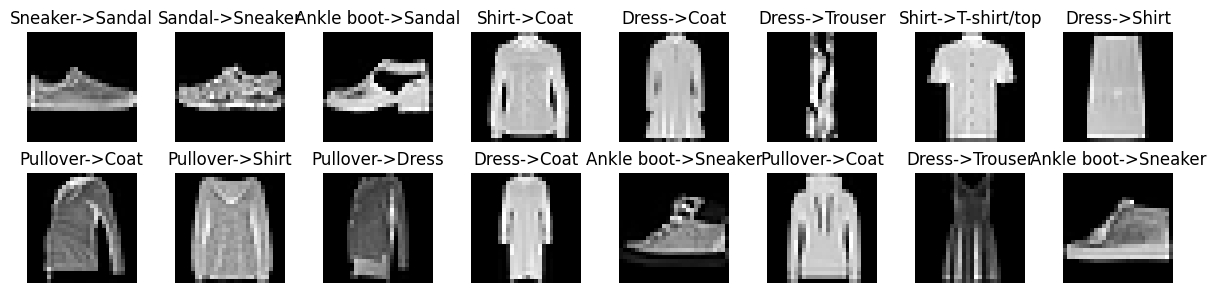

In [7]:
model.eval()
xb, yb = next(iter(test_loader))
with torch.no_grad():
    preds = model(xb.to(device)).argmax(1).cpu()
wrong = (preds != yb).nonzero(as_tuple=True)[0][:16]
show_grid(
    xb[wrong],
    titles=[f"{test_ds.classes[yb[i]]}->{test_ds.classes[preds[i]]}" for i in wrong],
    cols=8,
)

## Top-5 first-CNN bugs (memorize)

1. Forgot `.to(device)` for either the model or the batch.
2. Forgot `optimizer.zero_grad()` — gradients accumulate, training looks broken.
3. Forgot `model.eval()` during evaluation — BatchNorm/Dropout misbehave.
4. Wrong shape after `Flatten` — the `Linear` layer size doesn't match.
5. Used the same transform pipeline for train and test, including augmentations.

## You did it

You trained a CNN from scratch. Day 2 picks up here: deeper architectures,
transfer learning, and explainability.